In [31]:
import osmium
import osmium.filter
import osmium.osm
import osmium.geom
import pandana

In [32]:
# https://docs.osmcode.org/pyosmium/latest/user_manual/04-Working-with-Filters/

data= "../../denmark-260208.osm.pbf"
fp = osmium.FileProcessor(data).with_areas() \
    .with_filter(osmium.filter.EntityFilter(osmium.osm.NODE | osmium.osm.AREA))\
    .with_filter(osmium.filter.KeyFilter("amenity")
)

In [ ]:
# https://docs.osmcode.org/pyosmium/latest/user_manual/03-Working-with-Geometries/

from shapely import wkt
import pandas as pd

fab = osmium.geom.WKTFactory()

def to_row(o):
    if o.is_node():
        shape = wkt.loads(fab.create_point(o.location))
    elif o.is_way() and not o.is_closed():
        shape = wkt.loads(fab.create_linestring(o.nodes))
    elif o.is_area():
        shape = wkt.loads(fab.create_multipolygon(o))
    else:
        raise AssertionError(f"Unreachable: {o}")

    return {
        "x": shape.centroid.x,
        "y": shape.centroid.y,
        "value": 12345,
    }

df = pd.DataFrame.from_records([to_row(obj) for obj in fp])

In [34]:
display(df.head())
display(df.size)

,x,y,value
0,12.280136,55.652068,12345
1,12.277107,55.651657,12345
2,8.171297,55.720594,12345
3,12.691520,56.043311,12345
4,12.636254,55.657144,12345


566352

Generating contraction hierarchies with 24 threads.
Setting CH node vector of size 1215
Setting CH edge vector of size 1622
Range graph removed 42 edges of 3244
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
 100% 

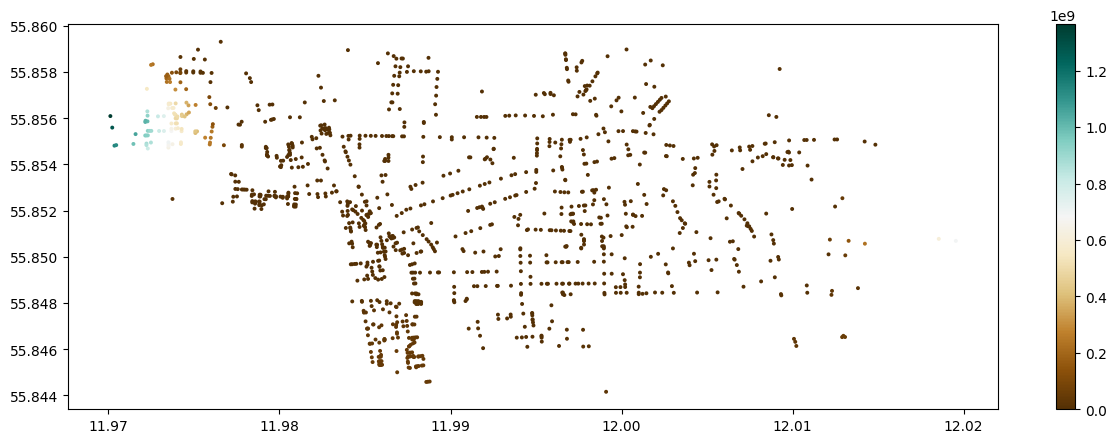

(<Figure size 1500x500 with 2 Axes>, <Axes: >)

In [ ]:
network = pandana.Network.from_hdf5("network.backup")
network = pandana.Network()
network.precompute(3000)

x, y = df.x,df.y
df["node_ids"] = network.get_node_ids(x, y)
network.set(df["node_ids"], variable=df.value, name="value")

aggregate = network.aggregate(500, type="sum", decay="linear", name="value")

bbox_jp = [55.845085, 11.970291, 55.858888, 12.014236]
network.plot(aggregate, bbox=bbox_jp,
         fig_kwargs={'figsize': [15, 5]},
         plot_kwargs={'cmap': 'BrBG', 's': 8, 'edgecolor': 'none'})